In [1]:
"""Check the output of the UQ"""
import xarray as xr
from utils.paths import *
from utils.analysis import *
import os
import itertools as it
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib import rcParams
from glob import glob
from tqdm import tqdm


rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 10
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

casename = 'UQ_default_US-SPR_ICB20TRCNPRDCTCBC'
casename_rerun = casename.replace('UQ_default', 'UQ_default_optimized')
n_rerun = 1000
pft_list = [2, 3, 11, 12]
hol_add = 17
chamber_list = ['T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2', 'TAMB']

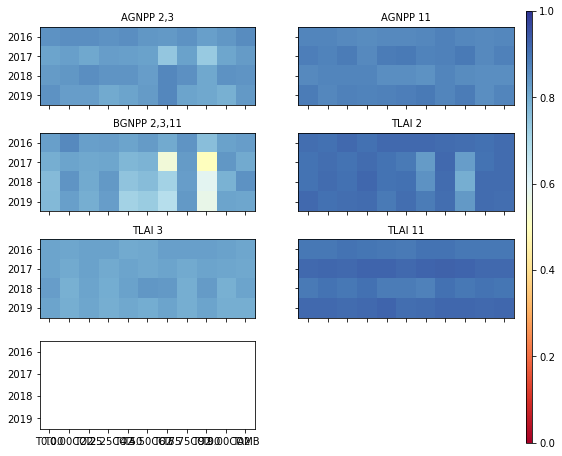

In [2]:
""" MCMC fitstats """

# Read the stats
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'NN_surrogate', 'fitstats.txt')
f = open(filename, 'r')
allstats = [re.split(r'\s+', line.split(': ')[1]) for line in f.read().split('\n') if line[:3] == 'QOI']
allstats = pd.DataFrame([[float(line[0]), float(line[1])] for line in allstats], index = range(len(allstats)), columns = ['R2', 'RMSE'])
f.close()

# Read the column names
postproc_vars = pd.read_csv('./temp/postproc_vars_SPRUCE', sep = r'\s+')
index = postproc_vars.iloc[:, [0, 1, 8, 11]]
index.columns = ['variable', 'year', 'pfts', 'chamber']
allstats.index = pd.MultiIndex.from_frame(index)

# Make the plot
var_and_pft = index[['variable', 'pfts']].drop_duplicates()
fig, axes = plt.subplots(3, 2, figsize = (8.5, 7.5), sharex = True, sharey = True)
count = 0
for _, row in var_and_pft.iterrows():
    ax = axes.flat[count]

    var = row['variable']
    pft = row['pfts']
    ax.set_title(f'{var} {pft}')

    try:
        temp = allstats.loc[(var, slice(None), pft, slice(None)), 'R2']
    except:
        ax.axis('off') # combination doesn't exist
        continue

    temp.index = temp.index.droplevel([0, 2])
    temp = temp.unstack()

    cf = ax.imshow(temp, vmin = 0, vmax = 1., cmap = 'RdYlBu')
    ax.set_xticks(range(temp.shape[1]))
    ax.set_xticklabels(temp.columns)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    ax.set_yticks(range(temp.shape[0]))
    ax.set_yticklabels(temp.index)

    count += 1
axes.flat[-1].axis('off')
cax = fig.add_axes([0.92, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, orientation = 'vertical')

In [2]:
""" Performance of the 1000 ELM runs sampled from the posterior parameter distributions """
###########################################################################################
# 1. Down-select to where all 4 PFTs grew
###########################################################################################
# n_rerun = 4000
# casename_rerun = casename

folders = [f'g{i:05g}' for i in range(1, n_rerun+1)]
grew = np.full((n_rerun, len(pft_list)), True)
for i in tqdm(range(n_rerun)):
    # pft_grew = True
    for chamber in chamber_list:
        flist = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', casename_rerun, folders[i], chamber, '*.h1.*.nc')))
        hr = xr.open_dataset(flist[0])
        gpp = hr['TLAI'].load() # * 86400 # s-1 to day-1
        for j, pft in enumerate(pft_list):
            if gpp[:, pft].max(axis = 0) < 1e-10:
                # pft_grew = False
                grew[i, j] = False
                # break
            if gpp[:, pft + hol_add].max(axis = 0) < 1e-10:
                # pft_grew = False
                grew[i, j] = False
                # break
"""
        if pft_grew == False:
            hr.close()
            break
        hr.close()
    grew[i] = pft_grew
folders_grew = [f for i, f in enumerate(folders) if grew[i]]
folders_grew
"""

 69%|██████▉   | 694/1000 [21:45<09:40,  1.90s/it]

In [66]:
np.sum(grew, axis = 0)

array([ 203,  999,    0, 1000])

In [67]:
pft_list

[2, 3, 11, 12]

In [17]:
###########################################################################################
# 2. Extract the variables and compare to the postproc file
###########################################################################################
observation = pd.read_csv(os.path.join(os.environ['HOME'], 'Git', 'phenology_elm', 'temp', 'postproc_vars_SPRUCE'), sep = r'\s+', header = None, skiprows = 1)
observation.columns = ['Variable','Startyear','Endyear','Startday','Endday','AveragingPeriod','Factor','AddOffset','PFT','Obs','Obs_err','Treatment']
simulation = pd.DataFrame(np.nan, index = range(observation.shape[0]), columns = folders_grew)
for i in range(len(folders_grew)):
    for j, row in observation.iterrows():
        filename = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', casename_rerun, folders_grew[i], row.loc['Treatment'], 
                               f'{casename_rerun}.clm2.h1.' + row.loc['Startyear'] + '-01-01-0000.nc')
        tvec = pd.date_range(row.loc['Startyear'] + '-01-01', row.loc['Endyear'] + '-12-31', freq = '1D')
        tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
        hr = xr.open_dataset(filename)
        val = hr[row.loc['Variable']][(tvec.day >= row.loc['Startday']) & (tvec.day <= row.loc['Endday']), :].load().mean(axis = 0)
        val_sum = row.loc['AddOffset']
        for pft, factor in zip(row['PFT'].split(','), row['Factor'].split(',')):
            pft = int(pft)
            val_sum = val_sum + (val[:, pft] * factor * 0.36 + val[:, pft + hol_add] * factor * 0.64)
        simulation.loc[j, i] = val_sum
        hr.close()